<a href="https://colab.research.google.com/github/Saad-web-spec/time-series-project/blob/feature%2Ffastapi-backend/Project_PINN_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.8 MB/s eta 0:00:00


In [15]:
!pip install dagshub mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.0/221.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [17]:
import dagshub
import mlflow
import mlflow.tensorflow

dagshub.init(repo_owner='saad.tatakae', repo_name='Intercooler-LSTM', mlflow=True)
mlflow.tensorflow.autolog()

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c3179dca-b3e5-43a5-86e1-187bfb8c84cd&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=074ccf18bf5b471b84219f03c38aa758f58c8443958bd8968057cbb3359d4274




Accessing as saad.tatakae

Initialized MLflow to track repo "saad.tatakae/Intercooler-LSTM"

Repository saad.tatakae/Intercooler-LSTM initialized!

In [ ]:
pip install tensorflow

In [ ]:
pip install seaborn

In [ ]:
pip install scikit-learn

In [2]:
#imports needed
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from datetime import datetime

In [5]:

file_path = '/content/drive/MyDrive/ffc_dataset_FINAL.csv'
df = pd.read_csv(file_path)
df.head()
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8001 entries, 0 to 8000
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hours_Elapsed           8001 non-null   int64  
 1   Gas_MassFlow_kgs        8001 non-null   float64
 2   Gas_Temp_In_C           8001 non-null   float64
 3   Gas_Temp_Out_C          8001 non-null   float64
 4   Gas_Press_In_bar        8001 non-null   float64
 5   Gas_Press_Out_bar       8001 non-null   float64
 6   Gas_PressureDrop_bar    8001 non-null   float64
 7   Water_MassFlow_kgs      8001 non-null   float64
 8   Water_Temp_In_C         8001 non-null   float64
 9   Water_Temp_Out_C        8001 non-null   float64
 10  Water_PressureDrop_bar  8001 non-null   float64
 11  Calculated_LMTD_C       8001 non-null   float64
 12  Calculated_U_Wm2K       8001 non-null   float64
 13  Target_Fouling_Rf       8001 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 8

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#data cleaning
df_cleaning = df[df['Gas_Temp_Out_C'] < 100].copy()

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaning)}")


Original rows: 8001
Cleaned rows: 7995


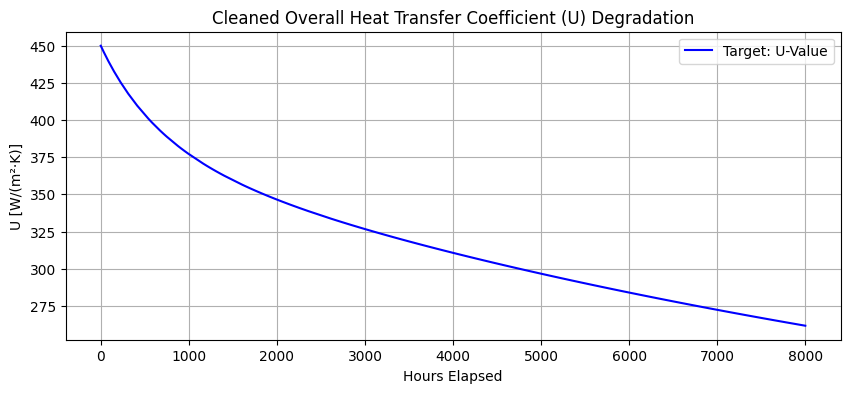

In [7]:
#Target output
plt.figure(figsize=(10, 4))
plt.plot(df_cleaning['Calculated_U_Wm2K'], color='blue', label='Target: U-Value')
plt.title('Cleaned Overall Heat Transfer Coefficient (U) Degradation')
plt.ylabel('U [W/(m²·K)]')
plt.xlabel('Hours Elapsed')
plt.legend()
plt.grid(True)
plt.show()

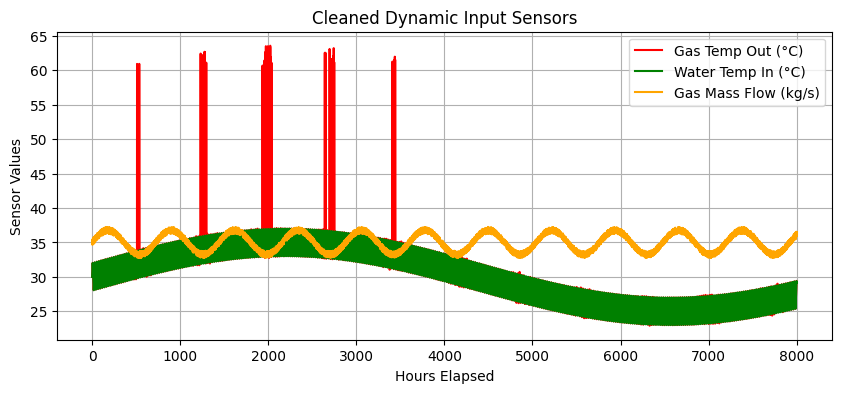

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(df_cleaning['Gas_Temp_Out_C'], color='red', label='Gas Temp Out (°C)')
plt.plot(df_cleaning['Water_Temp_In_C'], color='green', label='Water Temp In (°C)')
plt.plot(df_cleaning['Gas_MassFlow_kgs'], color='orange', label='Gas Mass Flow (kg/s)')
plt.title('Cleaned Dynamic Input Sensors')
plt.ylabel('Sensor Values')
plt.xlabel('Hours Elapsed')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Tighten the filter to remove the remaining 60-degree DWSIM glitches
df_cleaning = df[df['Gas_Temp_Out_C'] < 45].copy()

# Apply the rolling average to the CLEANED dataframe, not the raw one
df_smoothed = df_cleaning.rolling(window=12, min_periods=1).mean()


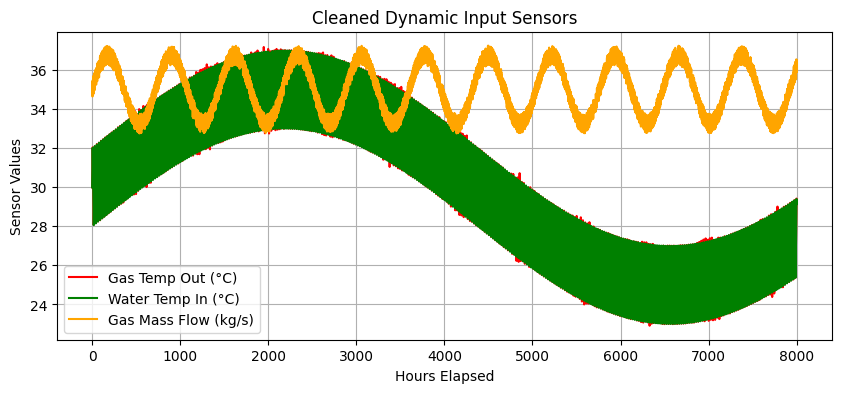

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(df_cleaning['Gas_Temp_Out_C'], color='red', label='Gas Temp Out (°C)')
plt.plot(df_cleaning['Water_Temp_In_C'], color='green', label='Water Temp In (°C)')
plt.plot(df_cleaning['Gas_MassFlow_kgs'], color='orange', label='Gas Mass Flow (kg/s)')
plt.title('Cleaned Dynamic Input Sensors')
plt.ylabel('Sensor Values')
plt.xlabel('Hours Elapsed')
plt.legend()
plt.grid(True)
plt.show()

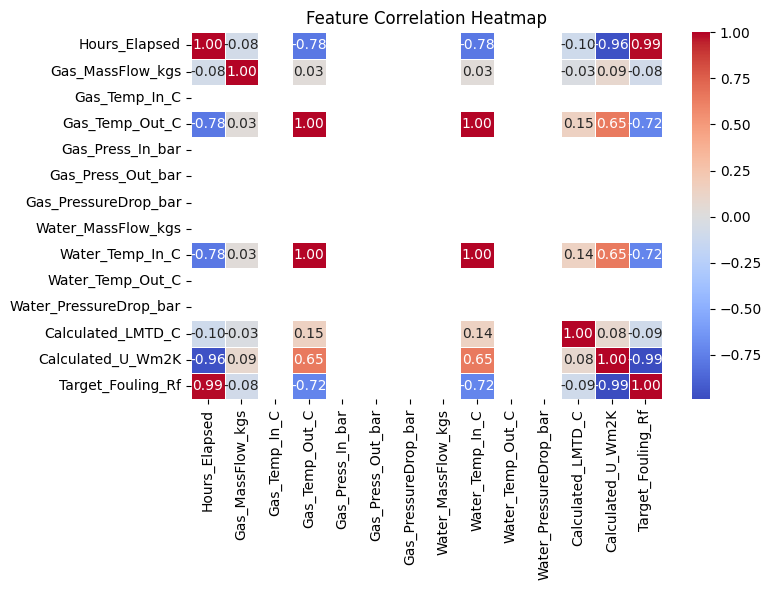

In [11]:
#to get how know of input and output features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(df_cleaning.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
#train/test split
feature_cols = ['Hours_Elapsed', 'Gas_MassFlow_kgs', 'Water_Temp_In_C', 'Gas_Temp_Out_C']
target_col = ['Calculated_U_Wm2K']

X_raw = df[feature_cols].values
y_raw = df[target_col].values

train_size = int(len(df) * 0.8)

X_train_raw = X_raw[:train_size]
X_test_raw = X_raw[train_size:]

y_train_raw = y_raw[:train_size]
y_test_raw = y_raw[train_size:]

print(f"Training rows: {len(X_train_raw)} | Testing rows: {len(X_test_raw)}")

Training rows: 6400 | Testing rows: 1601


In [ ]:
#Minmax scaling
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

print("First row of scaled X_train:", X_train_scaled[0])

First row of scaled X_train: [0.         0.49257222 0.49820789 0.06046631]


In [ ]:
#3D sliding windows

def create_3d_sequences(X, y, time_steps):
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        window = X[i : i + time_steps]
        target = y[i + time_steps]
        X_seq.append(window)
        y_seq.append(target)

    return np.array(X_seq), np.array(y_seq)


LOOKBACK = 72

X_train, y_train = create_3d_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_test, y_test = create_3d_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

print("--- FINAL TENSOR SHAPES ---")
print(f"X_train Shape: {X_train.shape} -> (Samples, Time Steps, Features)")
print(f"y_train Shape: {y_train.shape} -> (Samples, Target)")

--- FINAL TENSOR SHAPES ---
X_train Shape: (6328, 72, 4) -> (Samples, Time Steps, Features)
y_train Shape: (6328, 1) -> (Samples, Target)


Compiling model...
'compile' took 0.009852 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7c2827768e00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c2827768e00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.08e+02, 7.64e+00, 2.02e+03]    [1.08e+02, 7.64e+00, 2.02e+03]    []  
0 [5.00e+00, 2.60e+00]
1000      [6.69e-02, 2.78e-01, 3.50e-05]    [6.69e-02, 2.78e-01, 3.50e-05]    []  
1000 [4.85e+00, 2.75e+00]
2000      [1.42e-02, 2.01e-01, 8.21e-07]    [1.42e-02, 2.01e-01, 8.21e-07]    []  
2000 [4.83e+00, 2.87e+00]
3000      [8.44e-03, 1.51e-01, 1.48e-06]    [8.44e-03, 1.51e-01, 1.48e-06]    []  
3000 [4.81e+00, 3.0

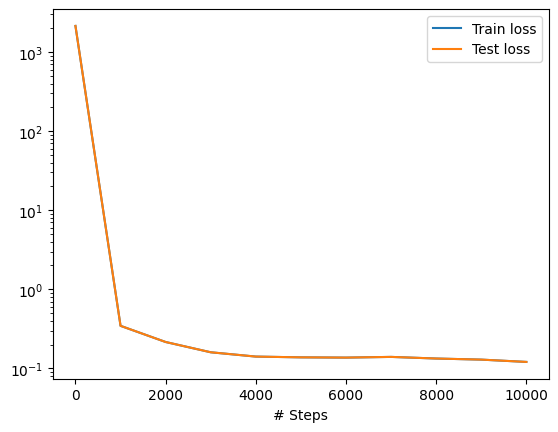

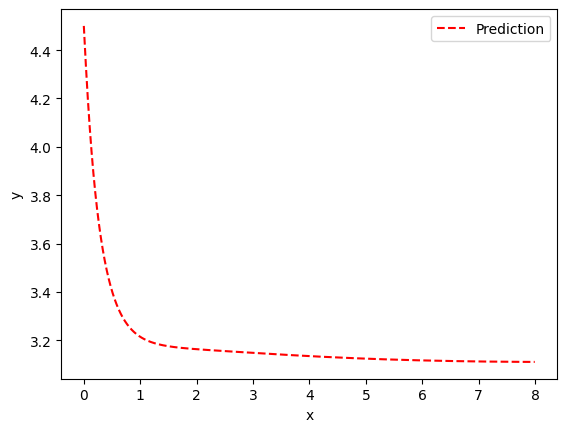

In [29]:
import deepxde as dde
import numpy as np
import mlflow

t_data = (df_smoothed['Hours_Elapsed'].values / 1000.0).reshape(-1, 1)
U_data = (df_smoothed['Calculated_U_Wm2K'].values / 100.0).reshape(-1, 1)

U_start = float(U_data[0][0])

k_var = dde.Variable(5.0)
U_min_var = dde.Variable(2.60)

def fouling_kinetics(t, U):
    dU_dt = dde.grad.jacobian(U, t)
    return dU_dt + k_var * (U - U_min_var)

geom = dde.geometry.TimeDomain(float(t_data.min()), float(t_data.max()))

observe_U = dde.icbc.PointSetBC(t_data, U_data, component=0)

def is_start_time(t, on_initial):
    return on_initial and np.isclose(t[0], float(t_data.min()))

ic = dde.icbc.IC(geom, lambda x: U_start, is_start_time)

data = dde.data.PDE(
    geom,
    fouling_kinetics,
    [observe_U, ic],
    num_domain=2000,
    anchors=t_data
)

net = dde.nn.FNN([1] + [64] * 3 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

model.compile(
    "adam",
    lr=0.001,
    external_trainable_variables=[k_var, U_min_var],
    loss_weights=[1, 1, 100]
)

variable_tracker = dde.callbacks.VariableValue([k_var, U_min_var], period=1000)

mlflow.set_tracking_uri('https://dagshub.com/saad.tatakae/Intercooler-LSTM.mlflow')
mlflow.set_experiment('Intercooler_U_Value_Prediction')

with mlflow.start_run(run_name='DeepXDE_PINN_Final_Weighted_IC'):
    losshistory, train_state = model.train(iterations=10000, callbacks=[variable_tracker])

    discovered_k = float(k_var.numpy())
    discovered_U_min = float(U_min_var.numpy())

    mlflow.log_metric("discovered_k_scaled", discovered_k)
    mlflow.log_metric("discovered_U_min_scaled", discovered_U_min)

    print(f"\n--- FINAL AI DISCOVERED PHYSICS ---")
    print(f"True Scaled Fouling Rate (k): {discovered_k:.4f}")
    print(f"True Scaled Minimum U-Value: {discovered_U_min:.4f}")

dde.saveplot(losshistory, train_state, issave=False, isplot=True)

In [30]:
# Save the trained PINN model
model.save("intercooler_pinn_model", verbose=1)
print("Model completely saved!")

Epoch 10000: saving model to intercooler_pinn_model-10000.weights.h5 ...

Model completely saved!


In [31]:
import mlflow

!zip -r pinn_model_files.zip intercooler_pinn_model*

mlflow.set_tracking_uri('https://dagshub.com/saad.tatakae/Intercooler-LSTM.mlflow')
mlflow.set_experiment('Intercooler_U_Value_Prediction')
with mlflow.start_run(run_name='Model_File_Upload'):


    mlflow.log_artifact("pinn_model_files.zip", artifact_path="final_model")
    print("Model successfully pushed to MLflow!")

  adding: intercooler_pinn_model-10000.weights.h5 (deflated 38%)
Model successfully pushed to MLflow!
🏃 View run Model_File_Upload at: https://dagshub.com/saad.tatakae/Intercooler-LSTM.mlflow/#/experiments/0/runs/bc0c64fc43a549158c6409fda9db23cf
🧪 View experiment at: https://dagshub.com/saad.tatakae/Intercooler-LSTM.mlflow/#/experiments/0
